In [5]:
from transformers import AutoTokenizer

# You can replace this with "mistralai/Mistral-7B-v0.1" or any other model you have locally
model_name = "camemBERT-base"  # For example, camemBERT-base or another model suited for French
tokenizer = AutoTokenizer.from_pretrained(model_name)

text_std = "Les femmes sont très joyeuses."
text_inc = "Les meufs sont très joyeuses."

# 1. Compare tokenization results
tokens_std = tokenizer.tokenize(text_std)
tokens_inc = tokenizer.tokenize(text_inc)

print(f"=== Tokenization Comparison ===")
print(f"Standard version ({len(tokens_std)} tokens): {tokens_std}")
print(f"Inclusive version ({len(tokens_inc)} tokens): {tokens_inc}")

# 2. Compute the fertility ratio
# Fertility = number of variant tokens / number of standard tokens
fertility = len(tokens_inc) / len(tokens_std)
print(f"Fertility ratio: {fertility:.2f}")

=== Tokenization Comparison ===
Standard version (7 tokens): ['▁Les', '▁femmes', '▁sont', '▁très', '▁joyeuse', 's', '.']
Inclusive version (9 tokens): ['▁Les', '▁me', 'uf', 's', '▁sont', '▁très', '▁joyeuse', 's', '.']
Fertility ratio: 1.29


In [8]:
import torch
from transformers import AutoModel, AutoTokenizer

# Assume model_name and the texts have already been defined
model_name = "camembert-base" 
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# text_std = "Les directeurs sont très compétents."
# text_inc = "Les directeur·trice·s sont très compétent·e·s."
from transformers import AutoTokenizer


# Pass the authentication token to the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# The rest of the code stays the same...
# Load the model and force it to return hidden states and attention matrices
model = AutoModel.from_pretrained(model_name, output_hidden_states=True, output_attentions=True)

# Convert the texts into tensors the model can process
inputs_std = tokenizer(text_std, return_tensors="pt")
inputs_inc = tokenizer(text_inc, return_tensors="pt")

# Run inference without gradients to save memory and compute
with torch.no_grad():
    outputs_std = model(**inputs_std)
    outputs_inc = model(**inputs_inc)

print("\n=== Internal Model Features (Strict Like-for-Like Comparison) ===")

# ==========================================
# 1. Hidden states comparison
# outputs.hidden_states contains all layers; we take the last one [-1]
# Expected shape: [batch_size, sequence_length, hidden_size]
# ==========================================
last_hidden_state_std = outputs_std.hidden_states[-1] 
last_hidden_state_inc = outputs_inc.hidden_states[-1] 

print("\n--- 1. Hidden States Shape Comparison ---")
print(f"Standard sentence: {last_hidden_state_std.shape}  -> sequence length is {last_hidden_state_std.shape[1]} tokens") 
print(f"Inclusive sentence: {last_hidden_state_inc.shape} -> sequence length jumps to {last_hidden_state_inc.shape[1]} tokens!") 


# ==========================================
# 2. Attention weights comparison
# outputs.attentions contains all layers; we also take the last one [-1]
# Expected shape: [batch_size, num_heads, sequence_length, sequence_length]
# ==========================================
last_layer_attention_std = outputs_std.attentions[-1]
last_layer_attention_inc = outputs_inc.attentions[-1]

print("\n--- 2. Attention Matrix Shape Comparison ---")
print(f"Standard sentence: {last_layer_attention_std.shape}   -> attention is computed on a {last_layer_attention_std.shape[2]} x {last_layer_attention_std.shape[3]} grid")
print(f"Inclusive sentence: {last_layer_attention_inc.shape} -> attention is spread across a {last_layer_attention_inc.shape[2]} x {last_layer_attention_inc.shape[3]} grid!")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1533.32it/s]
CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Internal Model Features (Strict Like-for-Like Comparison) ===

--- 1. Hidden States Shape Comparison ---
Standard sentence: torch.Size([1, 9, 768])  -> sequence length is 9 tokens
Inclusive sentence: torch.Size([1, 11, 768]) -> sequence length jumps to 11 tokens!

--- 2. Attention Matrix Shape Comparison ---
Standard sentence: torch.Size([1, 12, 9, 9])   -> attention is computed on a 9 x 9 grid
Inclusive sentence: torch.Size([1, 12, 11, 11]) -> attention is spread across a 11 x 11 grid!


In [9]:
print("Standard sentence tokens:", tokenizer.convert_ids_to_tokens(inputs_std["input_ids"][0]))
print("Inclusive sentence tokens:", tokenizer.convert_ids_to_tokens(inputs_inc["input_ids"][0]))

Standard sentence tokens: ['<s>', '▁Les', '▁femmes', '▁sont', '▁très', '▁joyeuse', 's', '.', '</s>']
Inclusive sentence tokens: ['<s>', '▁Les', '▁me', 'uf', 's', '▁sont', '▁très', '▁joyeuse', 's', '.', '</s>']


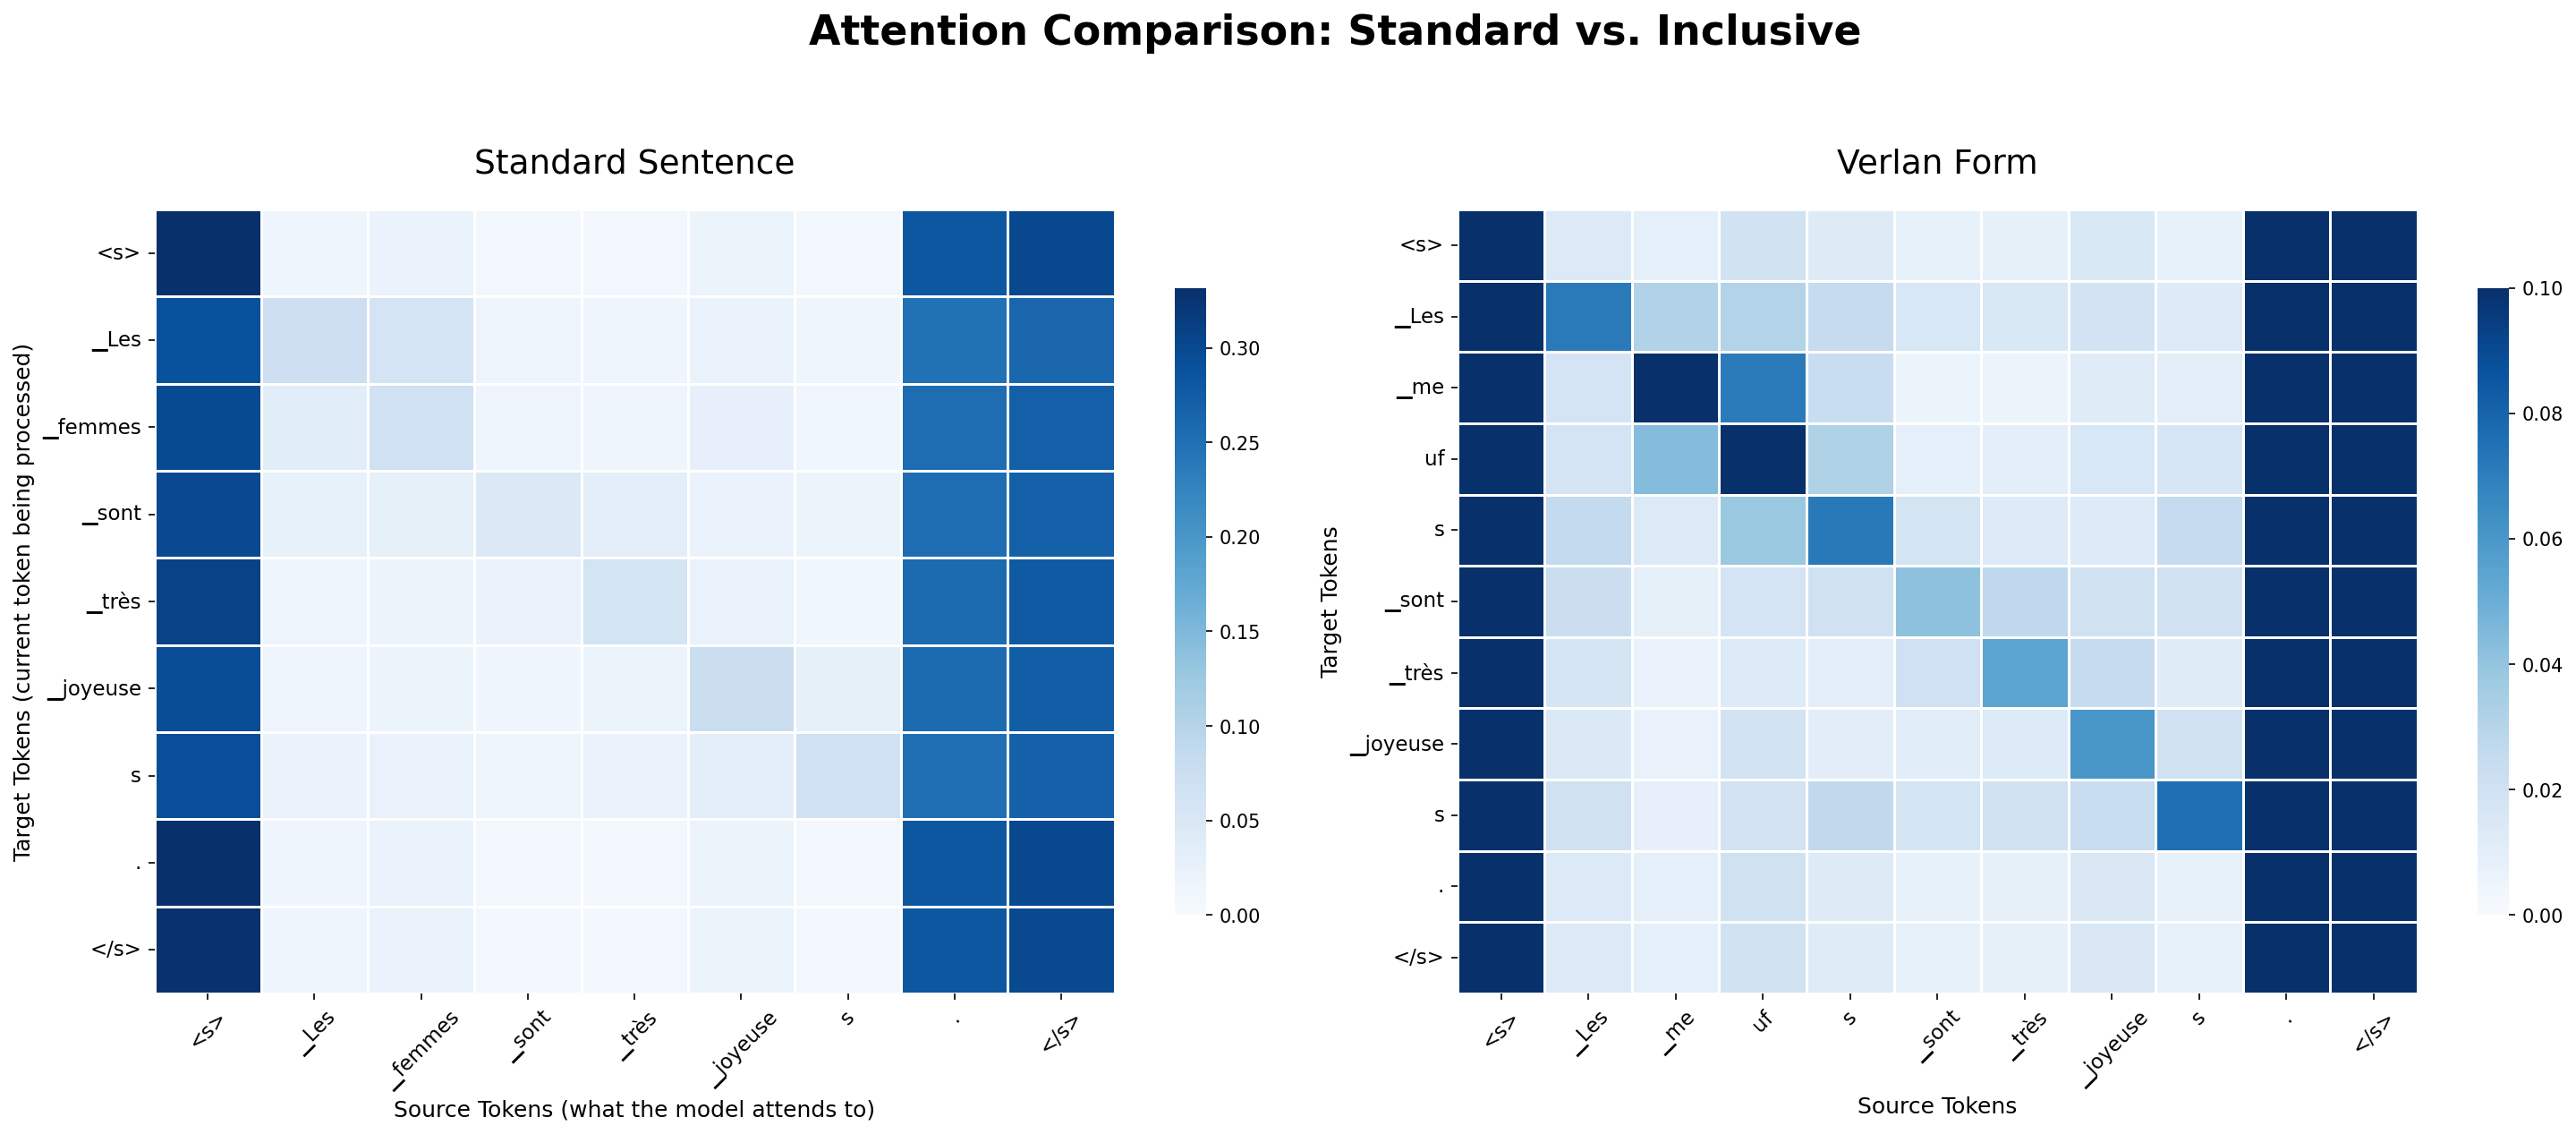

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ==========================================
# Step 1: Prepare token labels for the x-axis and y-axis
# ==========================================
# Convert input_ids back into human-readable token pieces
tokens_std = tokenizer.convert_ids_to_tokens(inputs_std["input_ids"][0])
tokens_inc = tokenizer.convert_ids_to_tokens(inputs_inc["input_ids"][0])

# ==========================================
# Step 2: Extract and process the attention matrices for both sentences
# ==========================================
# Take the last layer, remove the batch dimension, average over the 12 heads, and convert to NumPy
attention_matrix_std = outputs_std.attentions[-1].squeeze(0).mean(dim=0).detach().numpy()
attention_matrix_inc = outputs_inc.attentions[-1].squeeze(0).mean(dim=0).detach().numpy()

# To make the color intensity directly comparable, find the global maximum across both plots
# This ensures that the same dark blue corresponds to the same attention strength in each heatmap
global_max = max(attention_matrix_std.max(), attention_matrix_inc.max())

# ==========================================
# Step 3: Draw side-by-side comparison heatmaps
# ==========================================
# Create a 20x8 canvas with two subplots in one row (ax1 and ax2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

# --- Left plot: standard sentence (8x8) ---
sns.heatmap(attention_matrix_std, 
            ax=ax1, # Draw on the left subplot
            xticklabels=tokens_std, 
            yticklabels=tokens_std, 
            cmap="Blues", 
            linewidths=0.5, 
            vmin=0, vmax=global_max, # Shared color scale
            cbar_kws={"shrink": 0.8}) # Slightly shrink the color bar

ax1.set_title("Standard Sentence", fontsize=18, pad=20)
ax1.set_xlabel("Source Tokens (what the model attends to)", fontsize=12)
ax1.set_ylabel("Target Tokens (current token being processed)", fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=11)
ax1.tick_params(axis='y', rotation=0, labelsize=11)

# --- Right plot: inclusive form (16x16) ---
sns.heatmap(attention_matrix_inc, 
            ax=ax2, # Draw on the right subplot
            xticklabels=tokens_inc, 
            yticklabels=tokens_inc, 
            cmap="Blues", 
            linewidths=0.5, 
            vmin=0, vmax=0.1, # Shared color scale
            cbar_kws={"shrink": 0.8})

ax2.set_title("Verlan Form", fontsize=18, pad=20)
ax2.set_xlabel("Source Tokens", fontsize=12)
ax2.set_ylabel("Target Tokens", fontsize=12)
ax2.tick_params(axis='x', rotation=45, labelsize=11)
ax2.tick_params(axis='y', rotation=0, labelsize=11)

# ==========================================
# Step 4: Fine-tune the layout and display the figure
# ==========================================
# Add an overall title
plt.suptitle("Attention Comparison: Standard vs. Inclusive", fontsize=22, fontweight='bold', y=1.05)

# Automatically adjust spacing to avoid label overlap
plt.tight_layout()

# Show the high-resolution figure
plt.show()

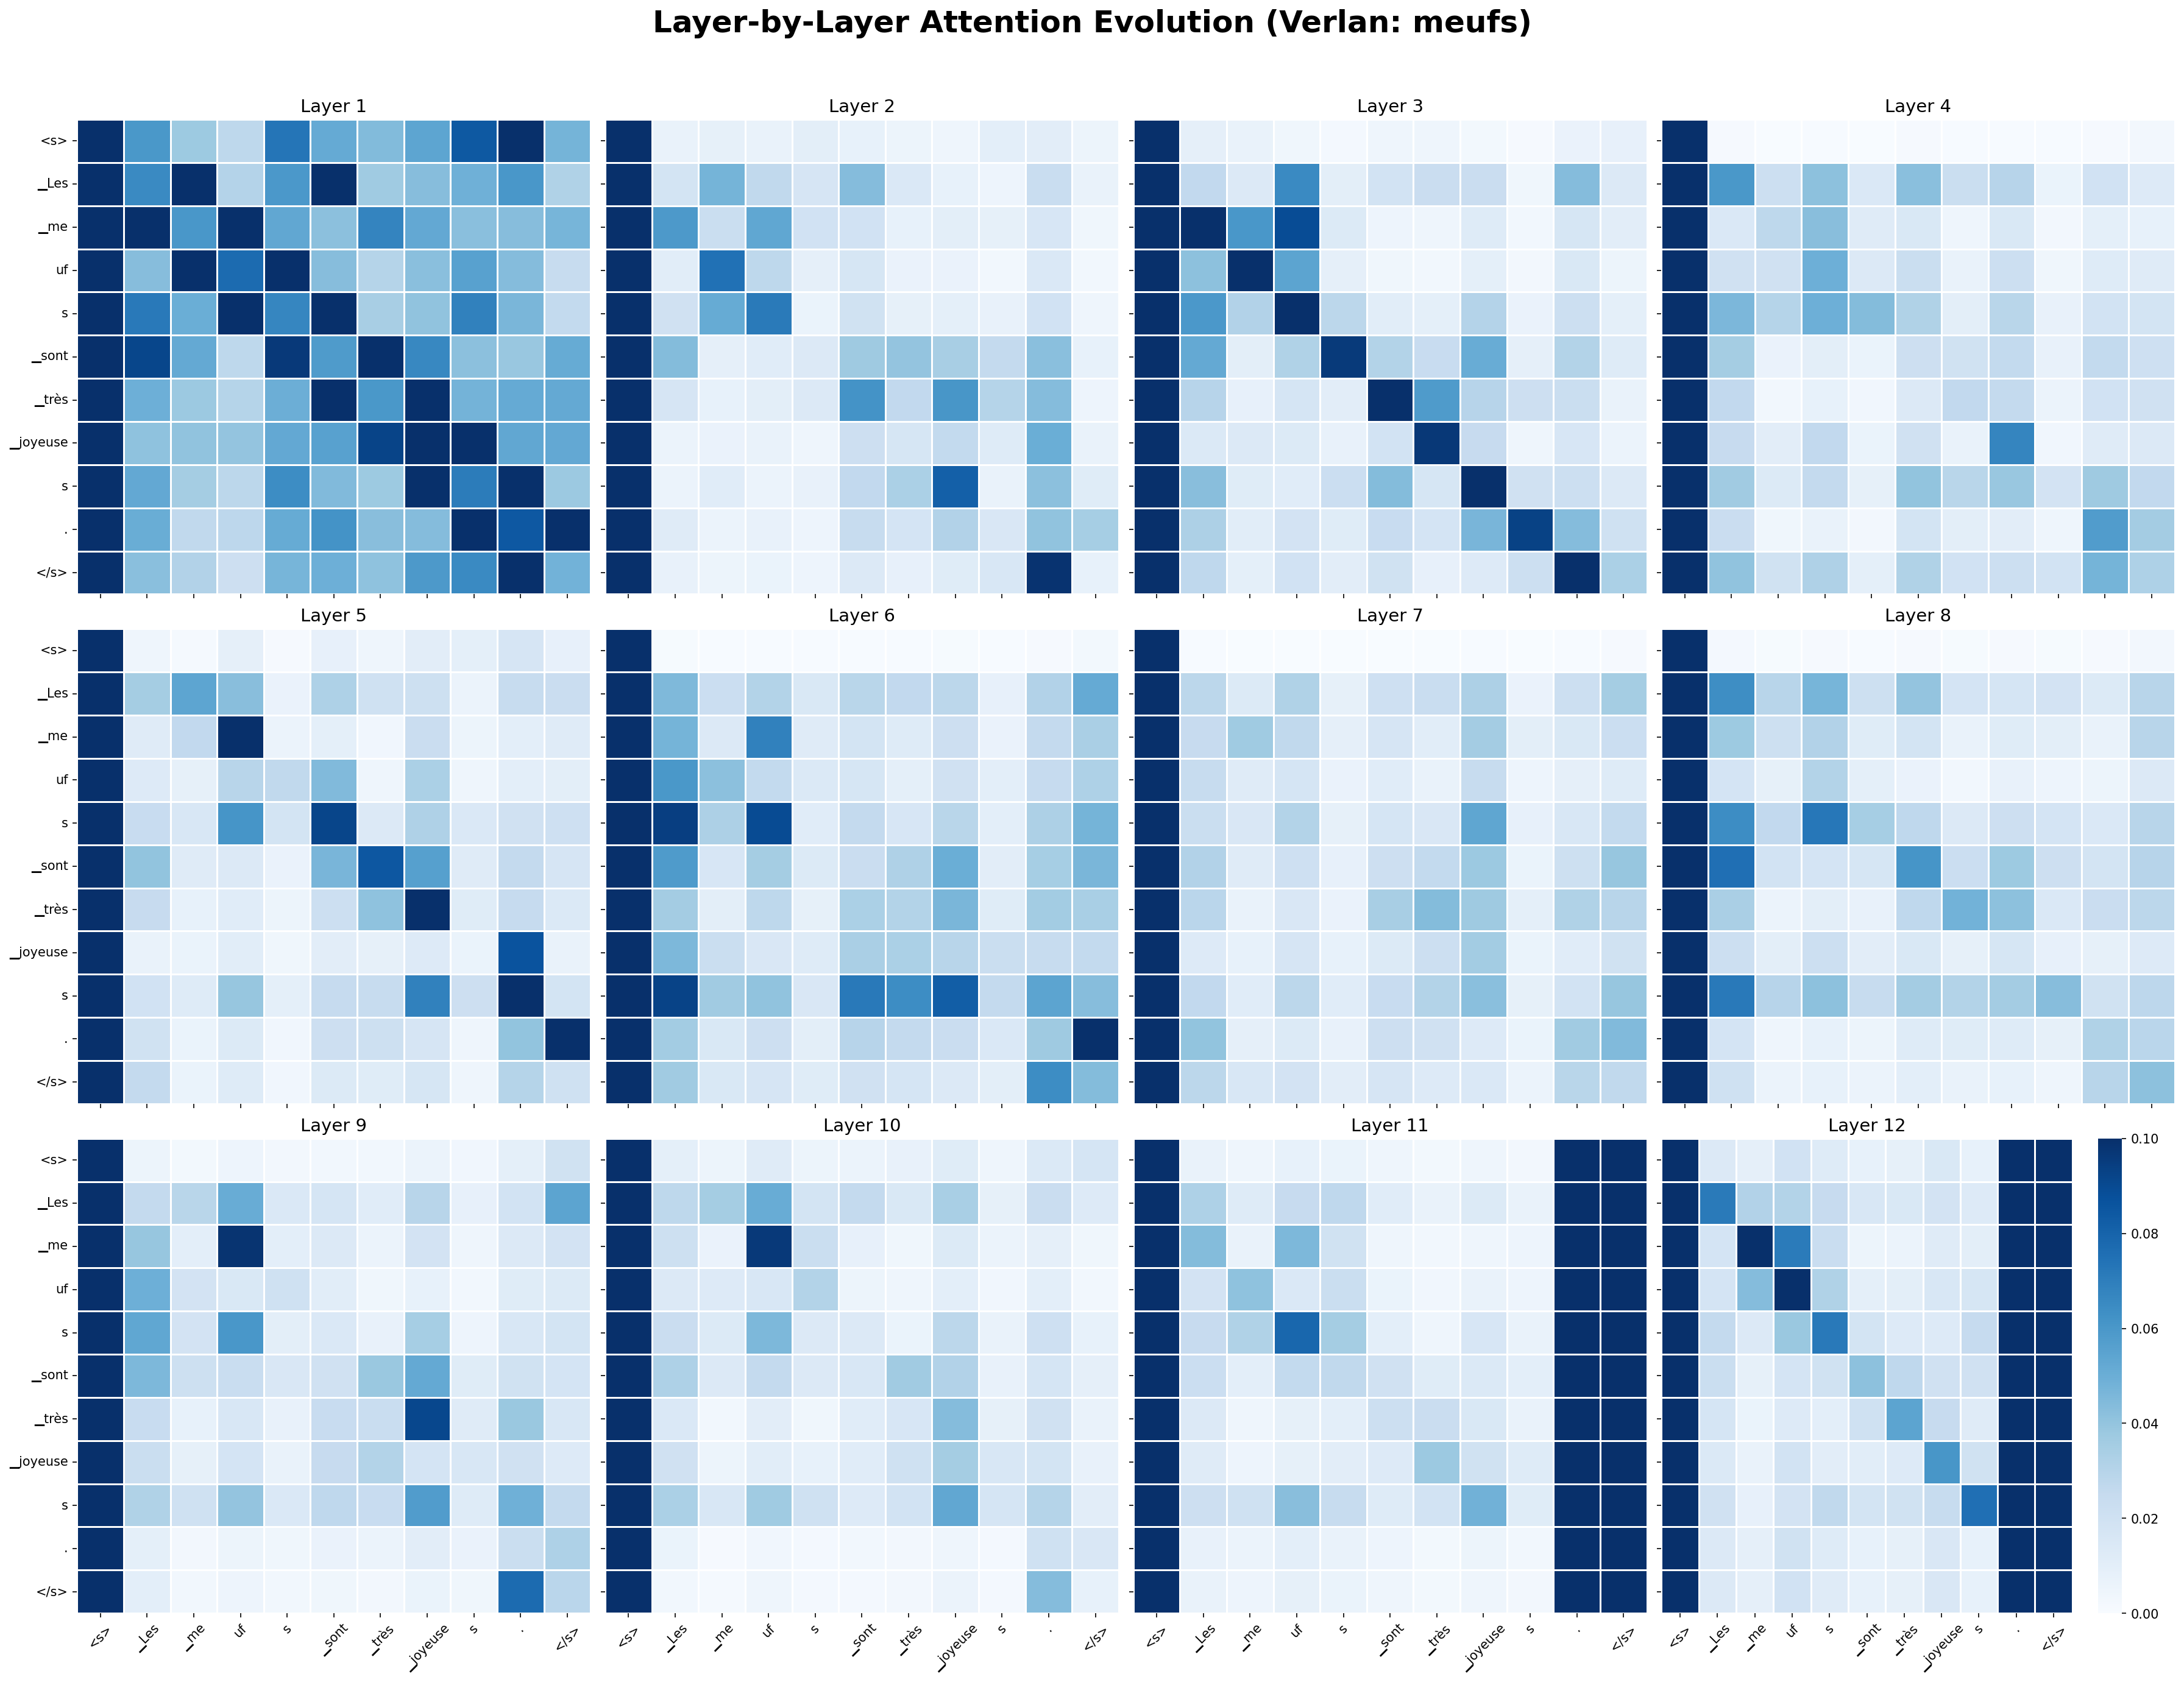

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import math

# Extract token labels for the Verlan sentence
tokens_inc = tokenizer.convert_ids_to_tokens(inputs_inc["input_ids"][0])

# Get the total number of model layers (typically 12 for a base model)
num_layers = len(outputs_inc.attentions)

# Create a 3x4 canvas (well suited for a 12-layer model)
fig, axes = plt.subplots(3, 4, figsize=(24, 18), dpi=150)
axes = axes.flatten() # Flatten the 2D axes array for easier looping

# Compute the maximum attention value across all layers for meaningful color comparison
global_max = 0
for i in range(num_layers):
    layer_attn = outputs_inc.attentions[i].squeeze(0).mean(dim=0).detach().numpy()
    global_max = max(global_max, layer_attn.max())

# Loop over every layer and draw the heatmap
for i in range(num_layers):
    # Extract the attention matrix for layer i and average across the 12 heads
    layer_attn = outputs_inc.attentions[i].squeeze(0).mean(dim=0).detach().numpy()
    
    # Draw the heatmap on the corresponding subplot
    sns.heatmap(layer_attn, 
                ax=axes[i], 
                xticklabels=tokens_inc,
                yticklabels=tokens_inc, 
                cmap="Blues", 
                linewidths=0.5,
                vmin=0, vmax=0.1, # Shared color scale
                cbar=(i == 11)) # Only show the color bar on the last subplot to keep the figure clean
    
    # Set the subplot title
    axes[i].set_title(f"Layer {i+1}", fontsize=14)
    
    # Adjust axis label sizes and hide inner tick labels to avoid clutter
    if i >= 8: # Only show x-axis labels on the bottom row
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)
    else:
        axes[i].set_xticklabels([])
        
    if i % 4 == 0: # Only show y-axis labels on the leftmost column
        axes[i].tick_params(axis='y', rotation=0, labelsize=10)
    else:
        axes[i].set_yticklabels([])

# Add an overall title
plt.suptitle("Layer-by-Layer Attention Evolution (Verlan: meufs)", fontsize=24, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

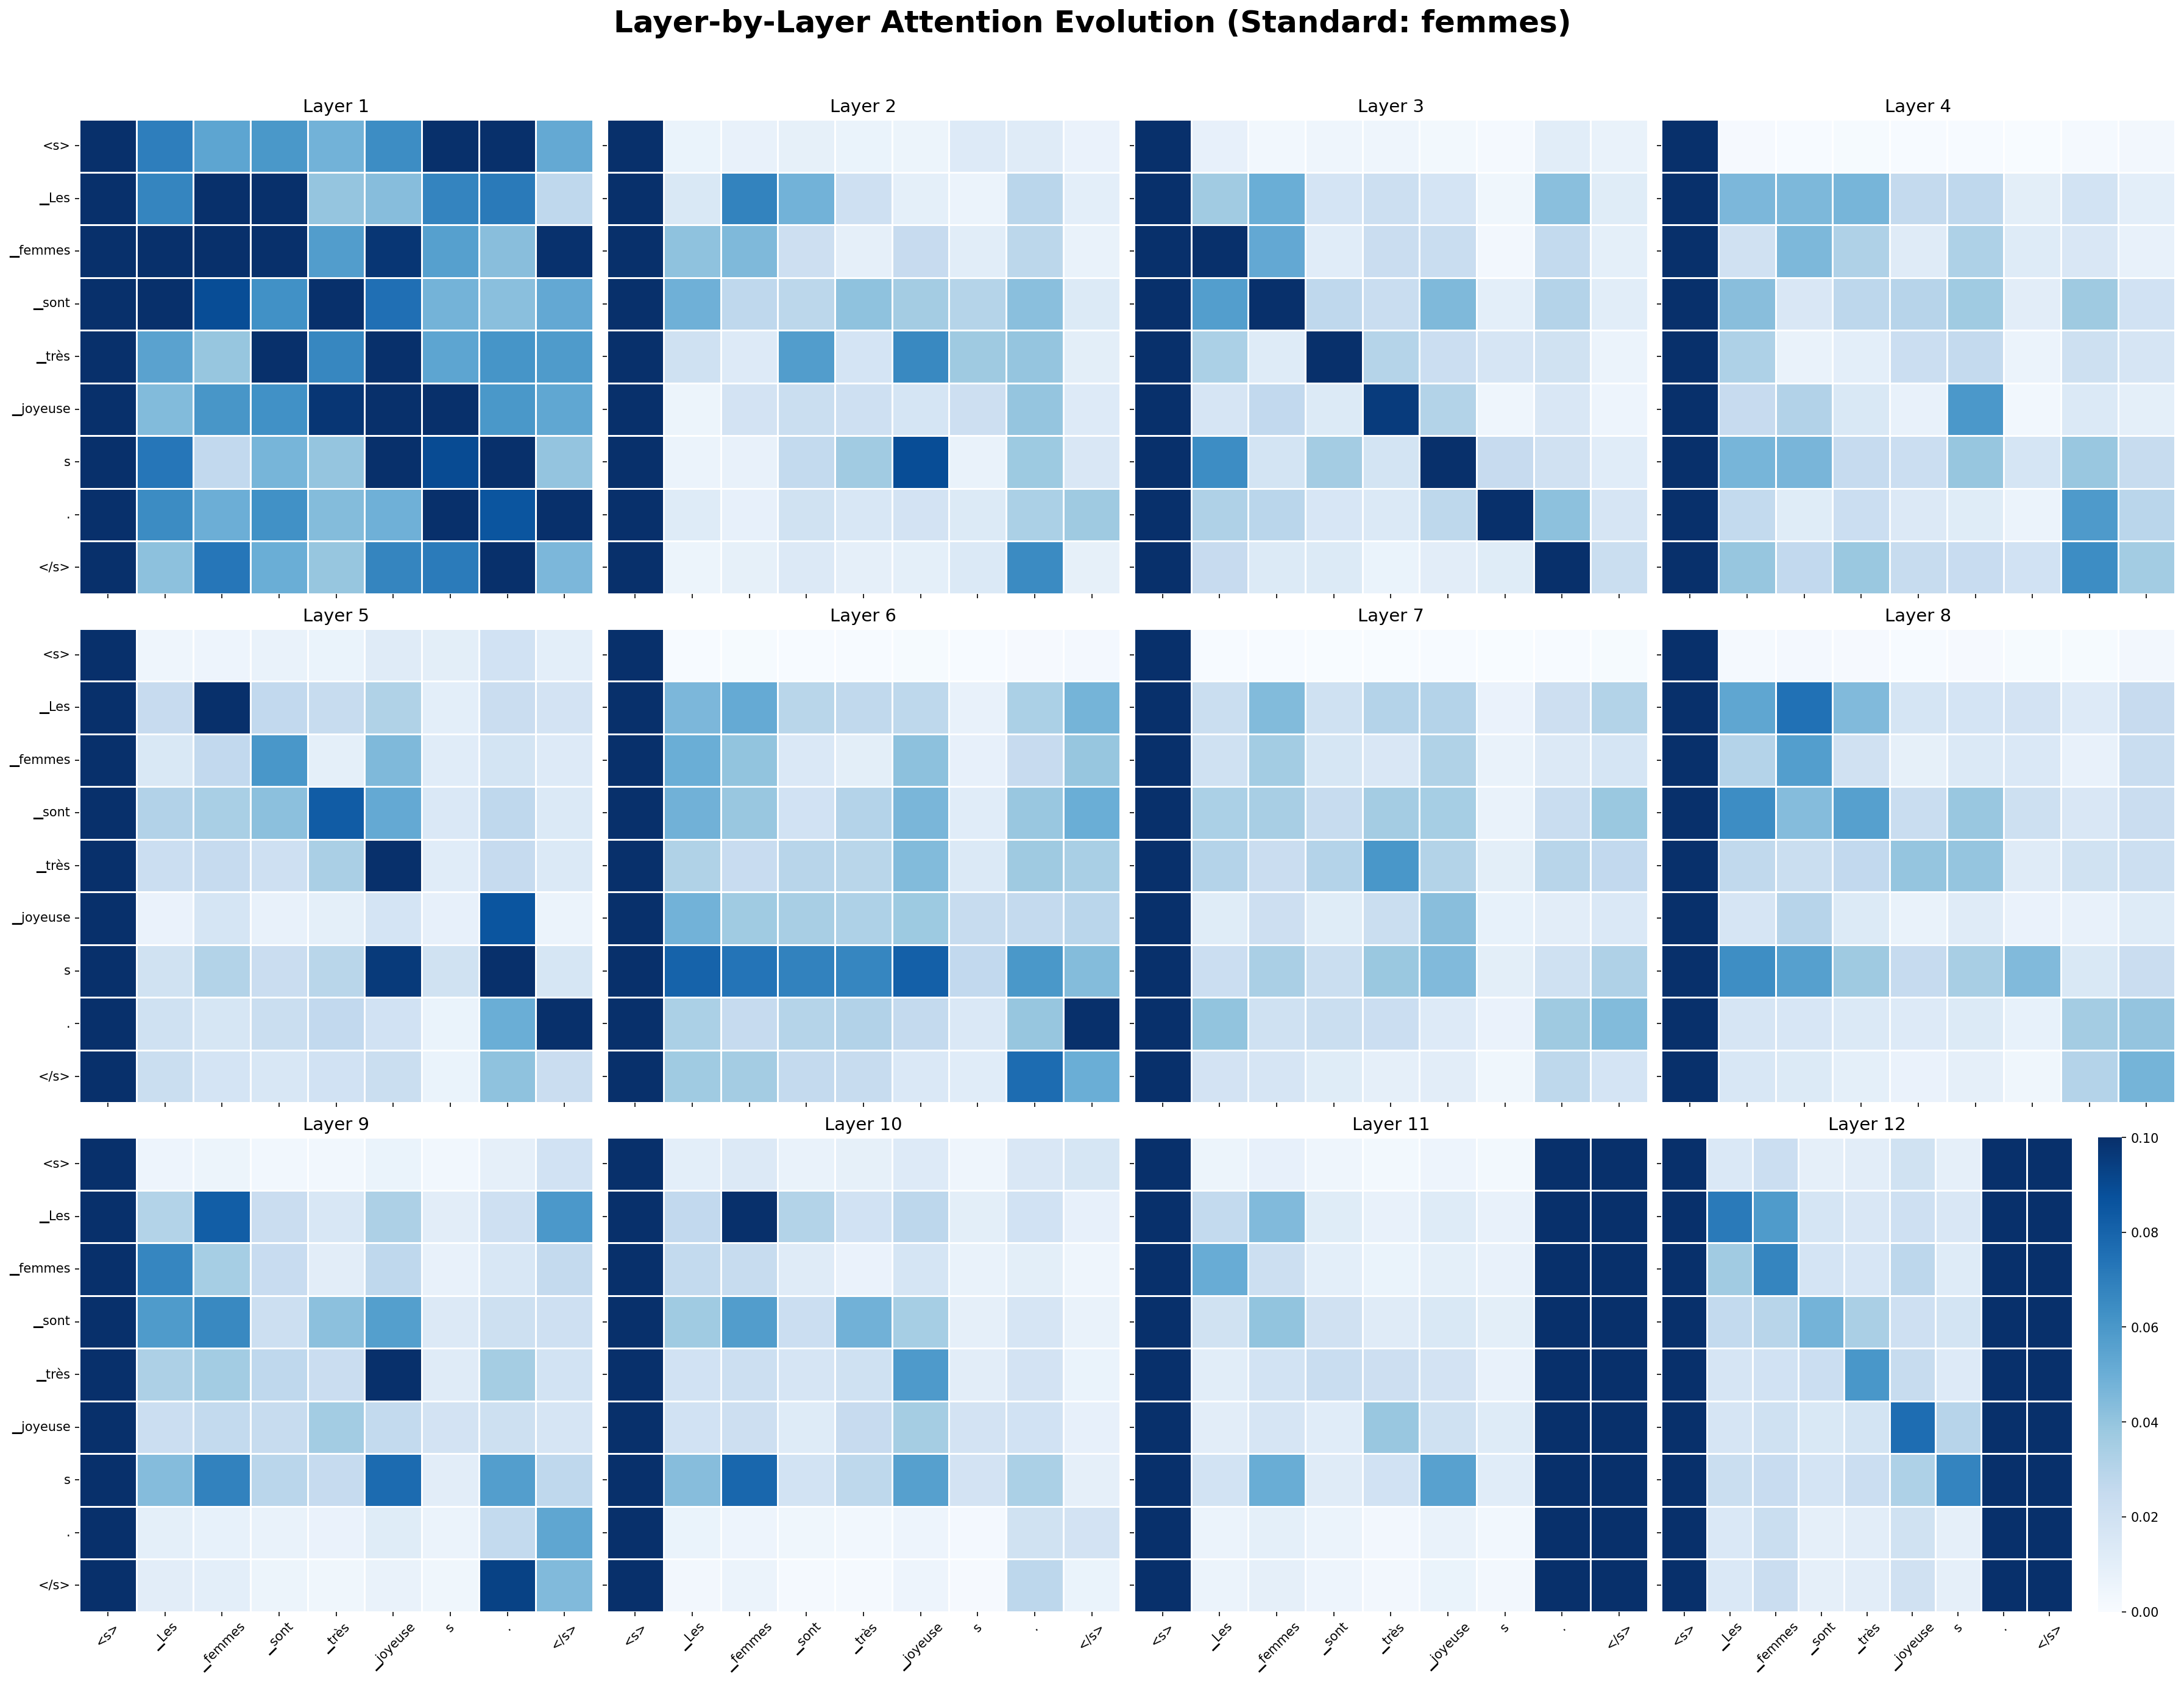

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import math

# Extract token labels for the standard sentence
tokens_inc = tokenizer.convert_ids_to_tokens(inputs_std["input_ids"][0])

# Get the total number of model layers (typically 12 for a base model)
num_layers = len(outputs_std.attentions)

# Create a 3x4 canvas (well suited for a 12-layer model)
fig, axes = plt.subplots(3, 4, figsize=(24, 18), dpi=150)
axes = axes.flatten() # Flatten the 2D axes array for easier looping

# Compute the maximum attention value across all layers for meaningful color comparison
global_max = 0
for i in range(num_layers):
    layer_attn = outputs_std.attentions[i].squeeze(0).mean(dim=0).detach().numpy()
    global_max = max(global_max, layer_attn.max())

# Loop over every layer and draw the heatmap
for i in range(num_layers):
    # Extract the attention matrix for layer i and average across the 12 heads
    layer_attn = outputs_std.attentions[i].squeeze(0).mean(dim=0).detach().numpy()
    
    # Draw the heatmap on the corresponding subplot
    sns.heatmap(layer_attn, 
                ax=axes[i], 
                xticklabels=tokens_inc,
                yticklabels=tokens_inc, 
                cmap="Blues", 
                linewidths=0.5,
                vmin=0, vmax=0.1, # Shared color scale
                cbar=(i == 11)) # Only show the color bar on the last subplot to keep the figure clean
    
    # Set the subplot title
    axes[i].set_title(f"Layer {i+1}", fontsize=14)
    
    # Adjust axis label sizes and hide inner tick labels to avoid clutter
    if i >= 8: # Only show x-axis labels on the bottom row
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)
    else:
        axes[i].set_xticklabels([])
        
    if i % 4 == 0: # Only show y-axis labels on the leftmost column
        axes[i].tick_params(axis='y', rotation=0, labelsize=10)
    else:
        axes[i].set_yticklabels([])

# Add an overall title
plt.suptitle("Layer-by-Layer Attention Evolution (Standard: femmes)", fontsize=24, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()